# ❤️ Heart Disease Prediction — End-to-End Mini Project

**Dataset:** Custom Heart Disease Dataset (10,000 patients, 20 features)  
**Target:** `Heart Disease Status` (Yes / No)  
**Models:** Logistic Regression · Random Forest  
**Stack:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

### 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Load & Explore Data](#2)
3. [Data Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Model Training](#5)
6. [Model Evaluation](#6)
7. [Feature Importance](#7)
8. [Prediction Function (Web App Simulation)](#8)
9. [Save Models](#9)

---
## 1. Setup & Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)#calculate accuracy,Measure model quality,	Precision Recall F1 score,
#ROC curve measure how good a classification model is
import pickle, json, os

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b',
    'ytick.color': '#64748b',
    'text.color': '#f1f5f9',
    'grid.color': '#334155',
    'grid.alpha': 0.5,
    'axes.titlecolor': '#f1f5f9',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 11
})
ACCENT = '#f43f5e'
BLUE   = '#3b82f6'
GREEN  = '#10b981'
AMBER  = '#f59e0b'

print('✅ All libraries imported successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')

✅ All libraries imported successfully!
   pandas  3.0.0
   numpy   2.4.1
   sklearn 1.8.0


---
## 2. Load & Explore Data

In [24]:
df = pd.read_csv('heart_disease.csv')

print('═' * 55)
print(f'  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('═' * 55)
df.head(3)

═══════════════════════════════════════════════════════
  Dataset Shape : 10,000 rows × 21 columns
═══════════════════════════════════════════════════════


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,Yes
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,Yes
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No


In [25]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = len(df)

df = pd.read_csv('heart_disease.csv')

# Rebuild the target based on actual risk logic
risk_score = (
    (df['Age'] > 55).astype(int) * 2 +
    (df['Smoking'] == 'Yes').astype(int) * 2 +
    (df['High Blood Pressure'] == 'Yes').astype(int) * 2 +
    (df['Cholesterol Level'] > 240).astype(int) * 1.5 +
    (df['BMI'] > 30).astype(int) * 1.5 +
    (df['Diabetes'] == 'Yes').astype(int) * 2 +
    (df['Family Heart Disease'] == 'Yes').astype(int) * 1.5 +
    (df['Alcohol Consumption'] == 'High').astype(int) * 1 +
    (df['Sleep Hours'] < 5).astype(int) * 1 +
    (df['Stress Level'] == 'High').astype(int) * 1
)

# Convert score to probability and assign labels
prob = 1 / (1 + np.exp(-(risk_score - 5)))  # sigmoid centered at 5
df['Heart Disease Status'] = np.where(
    np.random.random(n) < prob, 'Yes', 'No'
)

df.to_csv('heart_disease.csv', index=False)
print(df['Heart Disease Status'].value_counts())

Heart Disease Status
Yes    7014
No     2986
Name: count, dtype: int64


In [26]:
print('\n📌 Data Types & Non-Null Counts:')
df.info()


📌 Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15

In [27]:
print('📊 Numeric Feature Statistics:')
df.describe().round(2)

📊 Numeric Feature Statistics:


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.00,9981.00,9970.00,9978.00,9975.00,9974.00,9978.00,9974.00,9980.00
mean,49.30,149.76,225.43,29.08,6.99,250.73,120.14,7.47,12.46
std,18.19,17.57,43.58,6.31,1.75,87.07,23.58,4.34,4.32
min,18.00,120.00,150.00,18.00,4.00,100.00,80.00,0.00,5.00
25%,34.00,134.00,187.00,23.66,5.45,176.00,99.00,3.67,8.72
50%,49.00,150.00,226.00,29.08,7.00,250.00,120.00,7.47,12.41
75%,65.00,165.00,263.00,34.52,8.53,326.00,141.00,11.26,16.14
max,80.00,180.00,300.00,40.00,10.00,400.00,160.00,15.00,20.00


🎯 Target Variable Distribution:
───────────────────────────────────
  Yes  7,014  (70.1%)  ███████████████████████████████████
  No   2,986  (29.9%)  ██████████████


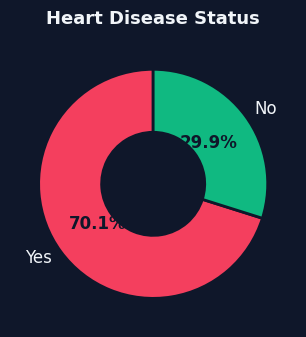

In [28]:
# Target distribution
counts = df['Heart Disease Status'].value_counts()
pcts   = df['Heart Disease Status'].value_counts(normalize=True) * 100

print('🎯 Target Variable Distribution:')
print('─' * 35)
for label in counts.index:
    bar = '█' * int(pcts[label] / 2)
    print(f'  {label:3s}  {counts[label]:,}  ({pcts[label]:.1f}%)  {bar}')

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = [ACCENT, GREEN]
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0f172a', linewidth=2),
    textprops={'color': '#f1f5f9', 'fontsize': 12}
)
for at in autotexts: at.set_color('#0f172a'); at.set_fontweight('bold')
ax.set_title('Heart Disease Status', pad=12)
fig.patch.set_facecolor('#0f172a')
plt.tight_layout()
plt.show()

⚠️  Columns with Missing Values:
                      Missing Count  Missing %
Alcohol Consumption            2586       25.9
Age                              29        0.3
CRP Level                        26        0.3
Cholesterol Level                30        0.3
Triglyceride Level               26        0.3
Sugar Consumption                30        0.3
Diabetes                         30        0.3
High Blood Pressure              26        0.3
High LDL Cholesterol             26        0.3
Fasting Blood Sugar              22        0.2
Sleep Hours                      25        0.2
Stress Level                     22        0.2
Low HDL Cholesterol              25        0.2
Gender                           19        0.2
BMI                              22        0.2
Family Heart Disease             21        0.2
Smoking                          25        0.2
Exercise Habits                  25        0.2
Blood Pressure                   19        0.2
Homocysteine Level         

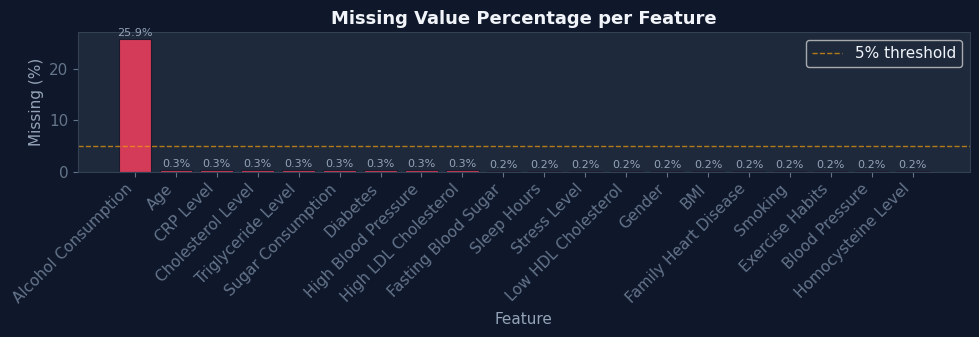

In [29]:
# Missing value heatmap
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('⚠️  Columns with Missing Values:')
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(missing_df.index, missing_df['Missing %'],
              color=ACCENT, alpha=0.85, edgecolor='#0f172a', linewidth=0.8)
ax.set_xlabel('Feature')
ax.set_ylabel('Missing (%)')
ax.set_title('Missing Value Percentage per Feature')
ax.axhline(5, color=AMBER, linestyle='--', linewidth=1, alpha=0.7, label='5% threshold')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color='#94a3b8')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

In [30]:
df_clean = df.copy()

# ── Step 1: Impute missing values ──────────────────────────────────
numeric_cols = df_clean.select_dtypes(include=[np.float64, float, int]).columns.tolist()
for col in numeric_cols:
    n = df_clean[col].isnull().sum()
    if n > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  Numeric  [{col}]: filled {n} NaNs → median={median_val:.2f}')

cat_cols_raw = [c for c in df_clean.columns
                if df_clean[c].dtype == object and c != 'Heart Disease Status']
for col in cat_cols_raw:
    n = df_clean[col].isnull().sum()
    if n > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'  Categor  [{col}]: filled {n} NaNs → mode="{mode_val}"')

print(f'\n✅ Missing after imputation: {df_clean.isnull().sum().sum()}')

  Numeric  [Age]: filled 29 NaNs → median=49.00
  Numeric  [Blood Pressure]: filled 19 NaNs → median=150.00
  Numeric  [Cholesterol Level]: filled 30 NaNs → median=226.00
  Numeric  [BMI]: filled 22 NaNs → median=29.08
  Numeric  [Sleep Hours]: filled 25 NaNs → median=7.00
  Numeric  [Triglyceride Level]: filled 26 NaNs → median=250.00
  Numeric  [Fasting Blood Sugar]: filled 22 NaNs → median=120.00
  Numeric  [CRP Level]: filled 26 NaNs → median=7.47
  Numeric  [Homocysteine Level]: filled 20 NaNs → median=12.41

✅ Missing after imputation: 2835


In [31]:
# ── Step 2: Encode categorical features ───────────────────────────
CAT_FEATURES = [
    'Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
    'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
    'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
    'Sugar Consumption'
]

encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le
    print(f'  Encoded [{col}]: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── Step 3: Create binary target ──────────────────────────────────
df_clean['target'] = (df_clean['Heart Disease Status'] == 'Yes').astype(int)

FEATURES = [c for c in df_clean.columns
            if c not in ['Heart Disease Status', 'target']]

X = df_clean[FEATURES]
y = df_clean['target']

print(f'\n✅ Feature matrix X: {X.shape}')
print(f'   Target vector  y: {y.shape}  (1=Disease: {y.sum():,}, 0=No Disease: {(y==0).sum():,})')

  Encoded [Gender]: {'Female': np.int64(0), 'Male': np.int64(1), nan: np.int64(2)}
  Encoded [Exercise Habits]: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), nan: np.int64(3)}
  Encoded [Smoking]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [Family Heart Disease]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [Diabetes]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [High Blood Pressure]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [Low HDL Cholesterol]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [High LDL Cholesterol]: {'No': np.int64(0), 'Yes': np.int64(1), nan: np.int64(2)}
  Encoded [Alcohol Consumption]: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), nan: np.int64(3)}
  Encoded [Stress Level]: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), nan: np.int64(3)}
  Encoded [Sugar Consumption]: {'High': np.int64(0), 'L

In [32]:
# ── Step 4: Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('📦 Data Split Summary')
print('─' * 30)
print(f'  Train : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Train disease rate: {y_train.mean()*100:.1f}%')
print(f'  Test  disease rate: {y_test.mean()*100:.1f}%  (stratified ✅)')

📦 Data Split Summary
──────────────────────────────
  Train : 8,000 rows (80%)
  Test  : 2,000 rows (20%)
  Train disease rate: 70.1%
  Test  disease rate: 70.2%  (stratified ✅)


---
## 4. Exploratory Data Analysis (EDA)

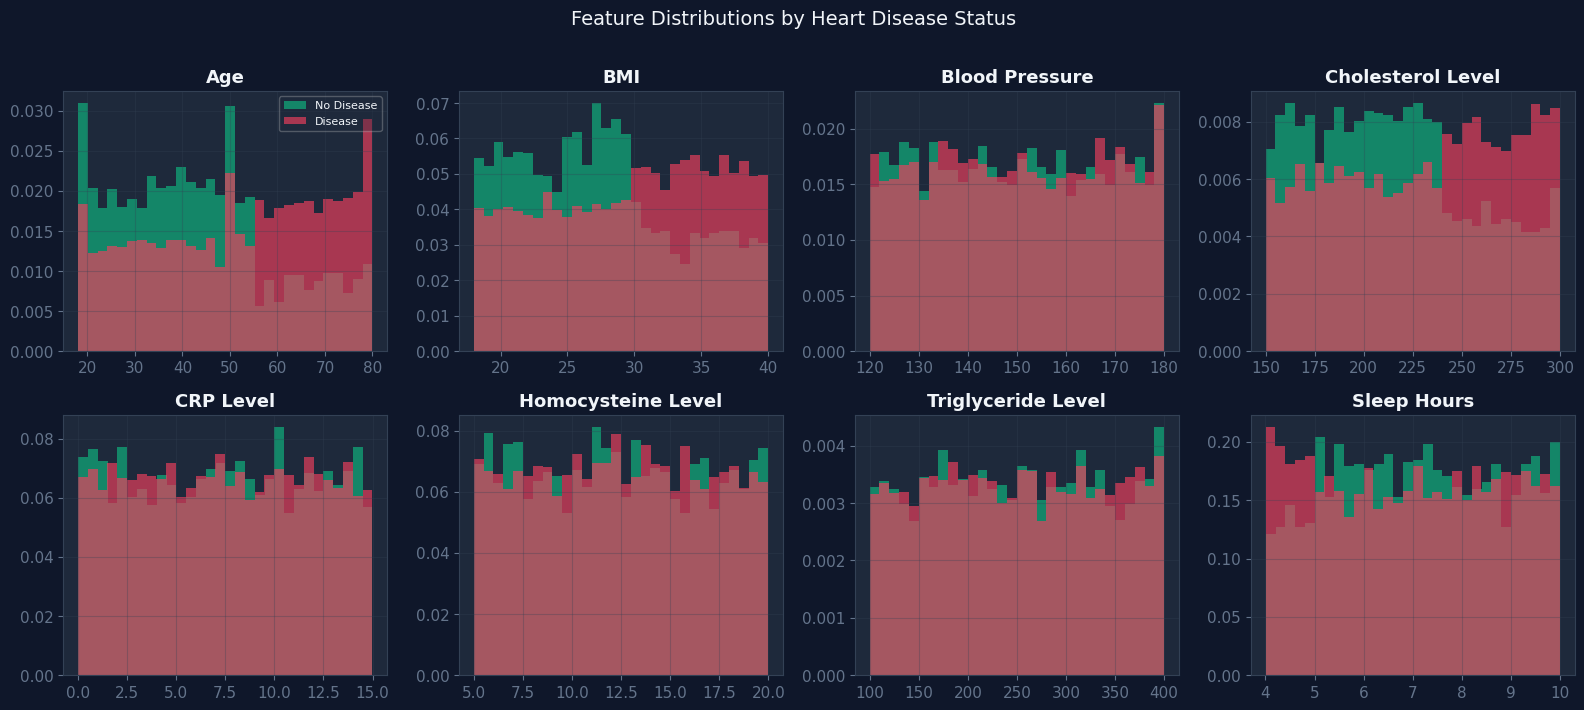

In [33]:
# Distribution of key numeric features by target
NUM_FEATS = ['Age', 'BMI', 'Blood Pressure', 'Cholesterol Level',
             'CRP Level', 'Homocysteine Level', 'Triglyceride Level', 'Sleep Hours']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(NUM_FEATS):
    ax = axes[i]
    for label, color, name in [(0, GREEN, 'No Disease'), (1, ACCENT, 'Disease')]:
        vals = df_clean[df_clean['target'] == label][feat]
        ax.hist(vals, bins=30, alpha=0.65, color=color, label=name, edgecolor='none', density=True)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, framealpha=0.3)

fig.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

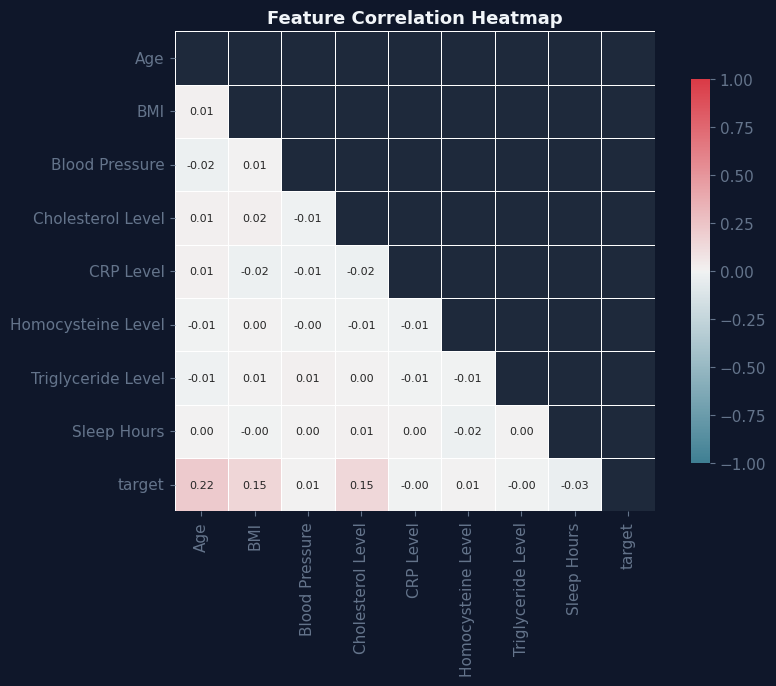

In [34]:
# Correlation heatmap
corr = df_clean[NUM_FEATS + ['target']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

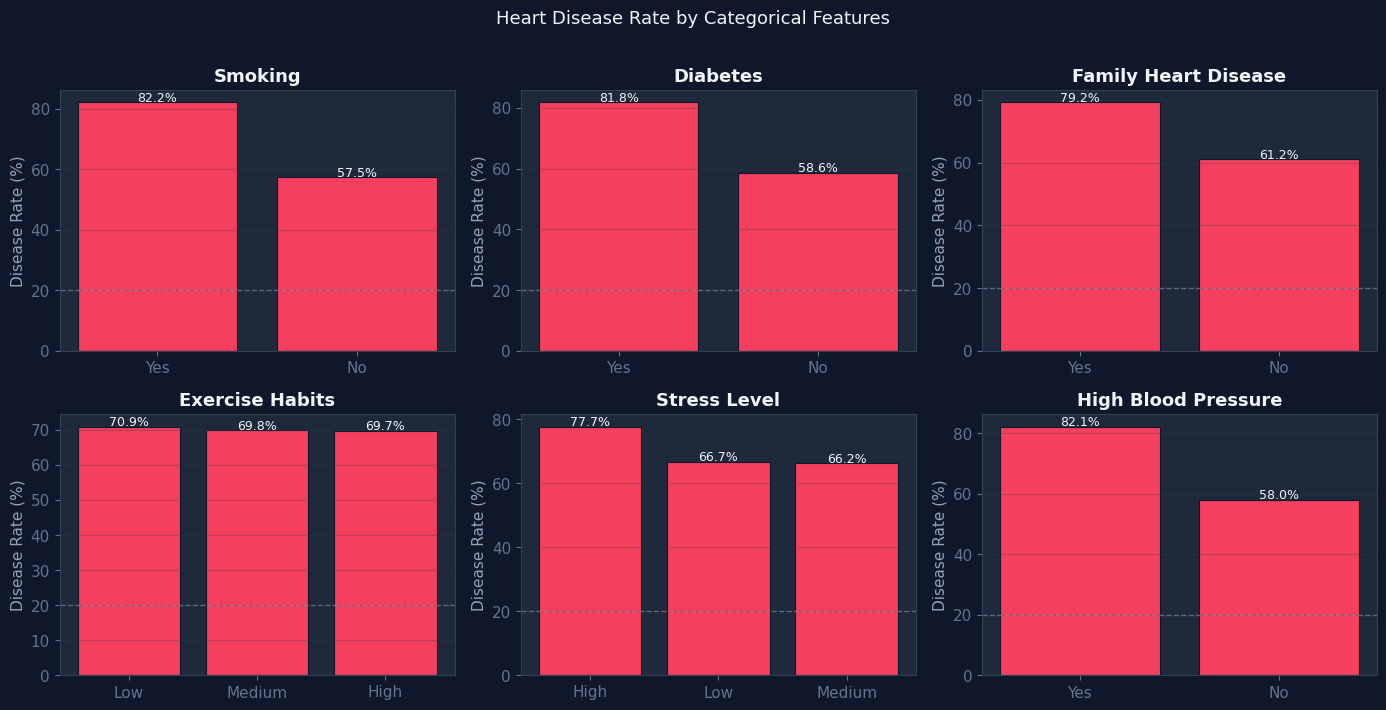

In [35]:
# Disease rate by categorical features
df_plot = df.copy()
df_plot['target'] = (df_plot['Heart Disease Status'] == 'Yes').astype(int)

cat_show = ['Smoking', 'Diabetes', 'Family Heart Disease',
            'Exercise Habits', 'Stress Level', 'High Blood Pressure']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(cat_show):
    ax = axes[i]
    rate = df_plot.groupby(col)['target'].mean() * 100
    rate = rate.sort_values(ascending=False)
    colors_bar = [ACCENT if v > 22 else AMBER if v > 18 else GREEN for v in rate.values]
    bars = ax.bar(rate.index, rate.values, color=colors_bar, edgecolor='#0f172a', linewidth=0.8)
    ax.set_title(col)
    ax.set_ylabel('Disease Rate (%)')
    ax.axhline(20, color='#94a3b8', linestyle='--', linewidth=1, alpha=0.5, label='Overall avg')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#f1f5f9')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Heart Disease Rate by Categorical Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Model Training

In [36]:
# ── Baseline: Logistic Regression ────────────────────────────────
print('🔵 Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_s, y_train)

lr_cv = cross_val_score(lr, scaler.transform(X), y, cv=5, scoring='roc_auc')
print(f'   5-Fold CV AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'   Test Accuracy: {accuracy_score(y_test, lr.predict(X_test_s)):.4f}')
print('   ✅ Done!')

🔵 Training Logistic Regression...
   5-Fold CV AUC: 0.8703 ± 0.0042
   Test Accuracy: 0.8125
   ✅ Done!


In [37]:
# ── Alternative: Random Forest ───────────────────────────────────
print('🌲 Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_cv = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'   5-Fold CV AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'   Test Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.4f}')
print('   ✅ Done!')

🌲 Training Random Forest...
   5-Fold CV AUC: 0.8818 ± 0.0085
   Test Accuracy: 0.8145
   ✅ Done!


---
## 6. Model Evaluation

In [38]:
# Classification Reports
models = {
    'Logistic Regression': (lr, X_test_s),
    'Random Forest':       (rf, X_test)
}

results = {}
for name, (model, X_t) in models.items():
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'acc': acc, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'\n{'═'*50}')
    print(f'  {name}')
    print(f'{'═'*50}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  AUC-ROC  : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))


══════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════
  Accuracy : 0.8125  (81.2%)
  AUC-ROC  : 0.8580

              precision    recall  f1-score   support

  No Disease       0.73      0.59      0.65       597
     Disease       0.84      0.91      0.87      1403

    accuracy                           0.81      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.81      0.81      0.81      2000


══════════════════════════════════════════════════
  Random Forest
══════════════════════════════════════════════════
  Accuracy : 0.8145  (81.5%)
  AUC-ROC  : 0.8738

              precision    recall  f1-score   support

  No Disease       0.75      0.57      0.65       597
     Disease       0.83      0.92      0.87      1403

    accuracy                           0.81      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.81      0.81      0.81      2000



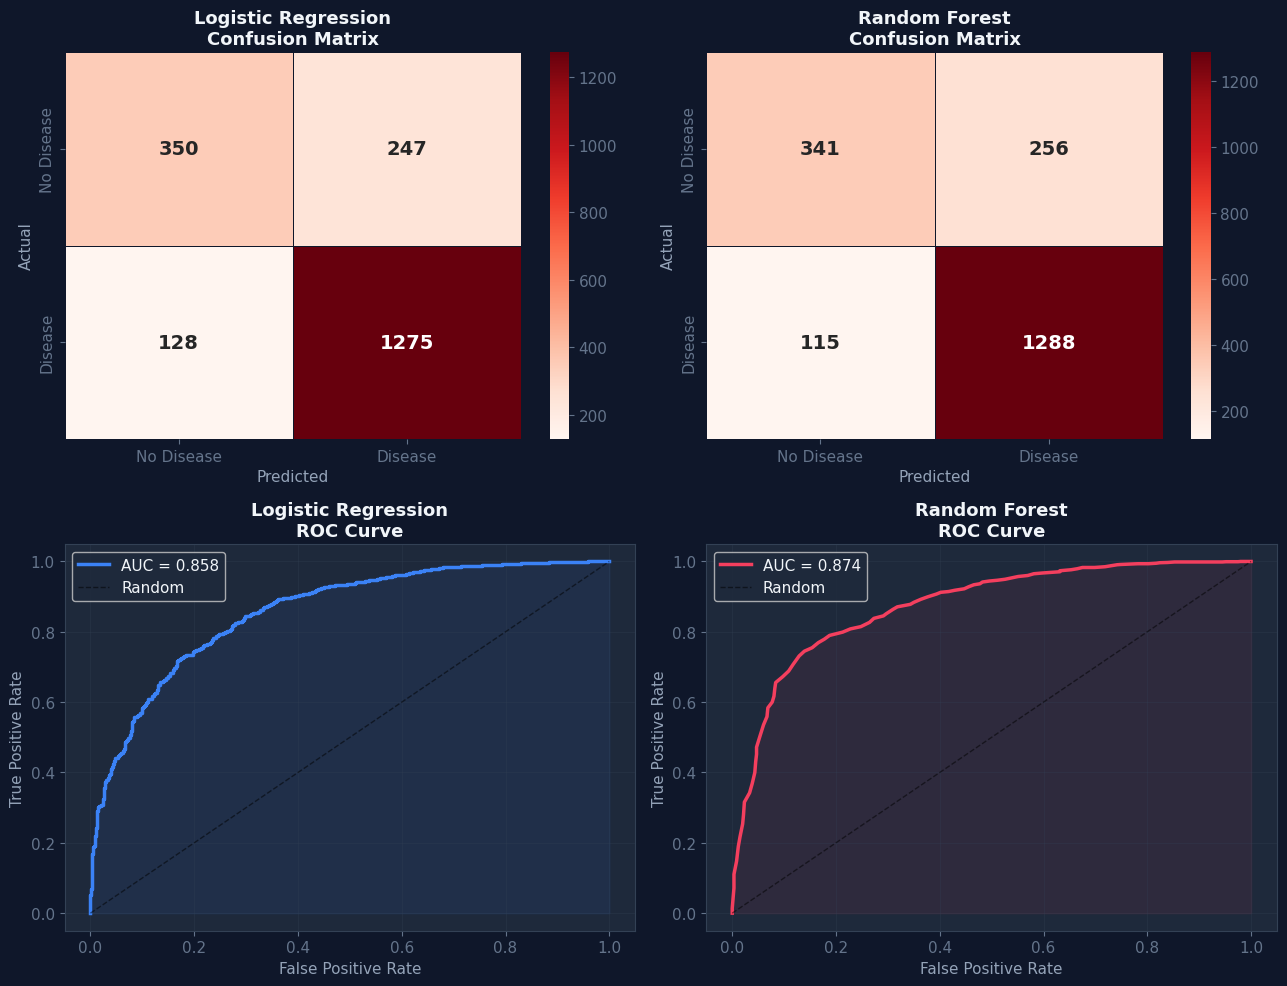

In [39]:
# Confusion Matrices + ROC Curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
model_colors = {'Logistic Regression': BLUE, 'Random Forest': ACCENT}

for col_idx, (name, (model, X_t)) in enumerate(models.items()):
    color = model_colors[name]
    r = results[name]

    # Confusion Matrix
    ax_cm = axes[0][col_idx]
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=ax_cm, linewidths=0.5, linecolor='#0f172a',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax_cm.set_title(f'{name}\nConfusion Matrix')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')

    # ROC Curve
    ax_roc = axes[1][col_idx]
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'AUC = {r["auc"]:.3f}')
    ax_roc.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax_roc.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{name}\nROC Curve')
    ax_roc.legend(fontsize=11)
    ax_roc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

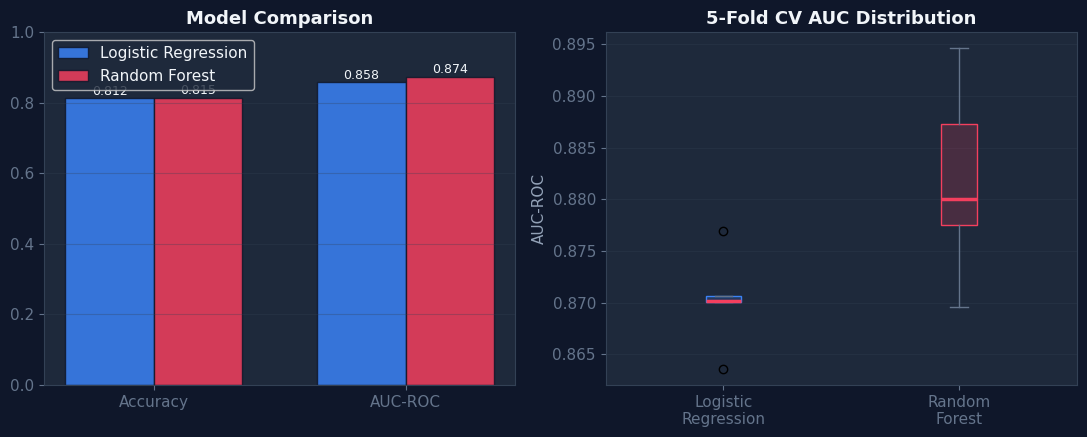


📊 Summary Table
────────────────────────────────────────────────────
  Model                       Accuracy    AUC-ROC
────────────────────────────────────────────────────
  Logistic Regression            81.2%     0.8580
  Random Forest                  81.5%     0.8738


In [40]:
# Cross-validation comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

metrics = ['Accuracy', 'AUC-ROC']
lr_vals = [results['Logistic Regression']['acc'], results['Logistic Regression']['auc']]
rf_vals = [results['Random Forest']['acc'],       results['Random Forest']['auc']]

x = np.arange(len(metrics))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, lr_vals, w, label='Logistic Regression', color=BLUE, alpha=0.85, edgecolor='#0f172a')
b2 = ax.bar(x + w/2, rf_vals, w, label='Random Forest',        color=ACCENT, alpha=0.85, edgecolor='#0f172a')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

# CV scores
ax2 = axes[1]
cv_data = {'Logistic\nRegression': lr_cv, 'Random\nForest': rf_cv}
bp = ax2.boxplot(list(cv_data.values()), patch_artist=True,
                 boxprops=dict(facecolor='#1e293b'),
                 medianprops=dict(color=ACCENT, linewidth=2.5),
                 whiskerprops=dict(color='#64748b'),
                 capprops=dict(color='#64748b'),
                 flierprops=dict(marker='o', color=AMBER, markersize=6))
for patch, color in zip(bp['boxes'], [BLUE, ACCENT]):
    patch.set_facecolor(color + '33')
    patch.set_edgecolor(color)
ax2.set_xticklabels(list(cv_data.keys()))
ax2.set_title('5-Fold CV AUC Distribution')
ax2.set_ylabel('AUC-ROC')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n📊 Summary Table')
print('─' * 52)
print(f'  {"Model":<25} {"Accuracy":>10} {"AUC-ROC":>10}')
print('─' * 52)
for name, r in results.items():
    print(f'  {name:<25} {r["acc"]*100:>9.1f}% {r["auc"]:>10.4f}')

---
## 7. Feature Importance

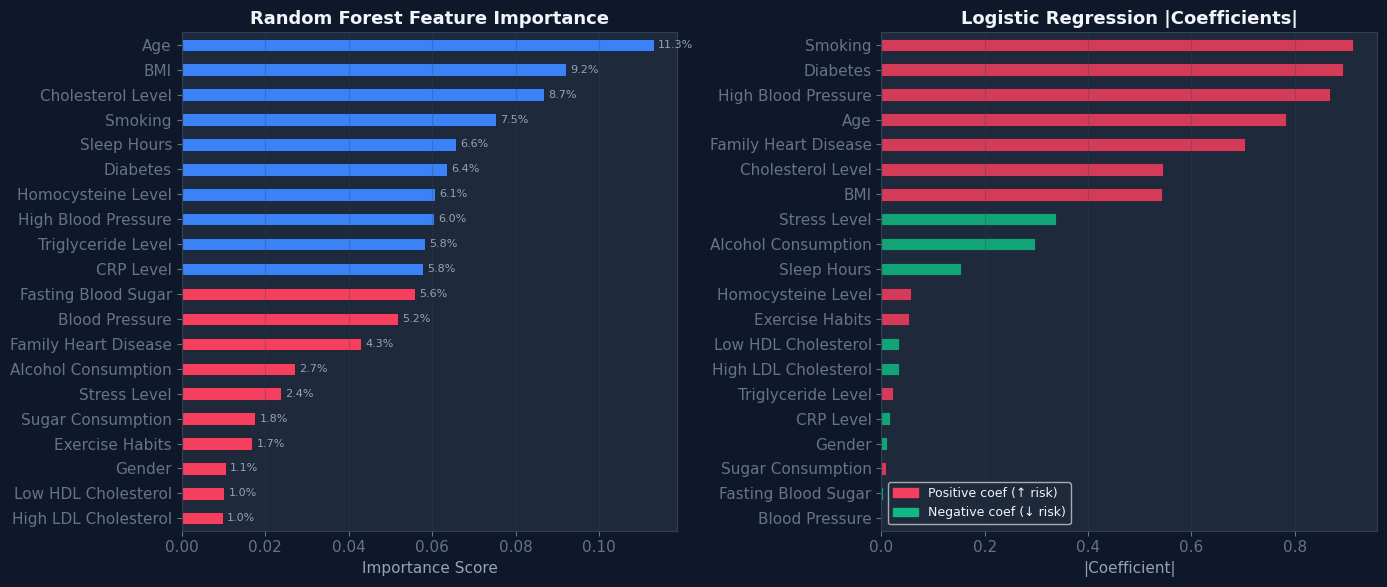


🏆 Top 10 Most Important Features (Random Forest):
   1. Age                        11.30%  ████████████████████████████████████████████████████████
   2. BMI                        9.20%  ██████████████████████████████████████████████
   3. Cholesterol Level          8.68%  ███████████████████████████████████████████
   4. Smoking                    7.52%  █████████████████████████████████████
   5. Sleep Hours                6.56%  ████████████████████████████████
   6. Diabetes                   6.35%  ███████████████████████████████
   7. Homocysteine Level         6.06%  ██████████████████████████████
   8. High Blood Pressure        6.04%  ██████████████████████████████
   9. Triglyceride Level         5.83%  █████████████████████████████
  10. CRP Level                  5.79%  ████████████████████████████


In [41]:
# Random Forest Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar
ax = axes[0]
colors_fi = [ACCENT if v > fi.median() else BLUE for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='#0f172a', linewidth=0.5)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
for i, (val, name) in enumerate(zip(fi.values, fi.index)):
    ax.text(val + 0.001, i, f'{val*100:.1f}%', va='center', fontsize=8, color='#94a3b8')

# Logistic Regression Coefficients
ax2 = axes[1]
coef = pd.Series(np.abs(lr.coef_[0]), index=FEATURES).sort_values(ascending=True)
coef_colors = [ACCENT if lr.coef_[0][FEATURES.index(f)] > 0 else GREEN for f in coef.index]
coef.plot(kind='barh', ax=ax2, color=coef_colors, edgecolor='#0f172a', linewidth=0.5, alpha=0.85)
ax2.set_title('Logistic Regression |Coefficients|')
ax2.set_xlabel('|Coefficient|')
ax2.grid(axis='x', alpha=0.3)
red_patch  = mpatches.Patch(color=ACCENT, label='Positive coef (↑ risk)')
blue_patch = mpatches.Patch(color=GREEN,  label='Negative coef (↓ risk)')
ax2.legend(handles=[red_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.show()

print('\n🏆 Top 10 Most Important Features (Random Forest):')
top10 = fi.sort_values(ascending=False).head(10)
for rank, (feat, imp) in enumerate(top10.items(), 1):
    bar = '█' * int(imp * 500)
    print(f'  {rank:2}. {feat:<25}  {imp*100:.2f}%  {bar}')

---
## 8. Prediction Function (Web App Simulation)

In [42]:
def predict_heart_disease(patient_data: dict, model_type: str = 'rf') -> dict:
    """
    Predict heart disease risk for a single patient.
    
    Parameters
    ----------
    patient_data : dict  — feature name → value
    model_type   : str   — 'rf' (Random Forest) or 'lr' (Logistic Regression)
    
    Returns
    -------
    dict with keys: prediction, probability, risk_level, top_risk_factors
    """
    row = []
    for feat in FEATURES:
        val = patient_data.get(feat)
        if feat in encoders:
            val = encoders[feat].transform([str(val)])[0]
        row.append(float(val))

    X_input = np.array(row).reshape(1, -1)

    if model_type == 'lr':
        proba = lr.predict_proba(scaler.transform(X_input))[0][1]
    else:
        proba = rf.predict_proba(X_input)[0][1]

    if proba < 0.30:
        risk = '🟢 LOW'
    elif proba < 0.55:
        risk = '🟡 MODERATE'
    else:
        risk = '🔴 HIGH'

    # Top risk factors from RF
    fi_series = pd.Series(rf.feature_importances_, index=FEATURES)
    top_factors = fi_series.sort_values(ascending=False).head(5).index.tolist()

    return {
        'prediction':       'Disease' if proba > 0.5 else 'No Disease',
        'probability':      round(float(proba) * 100, 1),
        'risk_level':       risk,
        'model_used':       'Random Forest' if model_type == 'rf' else 'Logistic Regression',
        'top_risk_factors': top_factors
    }

print('✅ predict_heart_disease() function ready!')

✅ predict_heart_disease() function ready!


In [43]:
# ── Example Predictions ───────────────────────────────────────────

# Patient 1: High-risk profile
patient_high_risk = {
    'Age': 65, 'Gender': 'Male', 'Blood Pressure': 175,
    'Cholesterol Level': 290, 'Exercise Habits': 'Low',
    'Smoking': 'Yes', 'Family Heart Disease': 'Yes', 'Diabetes': 'Yes',
    'BMI': 36.0, 'High Blood Pressure': 'Yes', 'Low HDL Cholesterol': 'Yes',
    'High LDL Cholesterol': 'Yes', 'Alcohol Consumption': 'High',
    'Stress Level': 'High', 'Sleep Hours': 5.0, 'Sugar Consumption': 'High',
    'Triglyceride Level': 390, 'Fasting Blood Sugar': 155,
    'CRP Level': 14.0, 'Homocysteine Level': 19.0
}

# Patient 2: Low-risk profile
patient_low_risk = {
    'Age': 28, 'Gender': 'Female', 'Blood Pressure': 122,
    'Cholesterol Level': 160, 'Exercise Habits': 'High',
    'Smoking': 'No', 'Family Heart Disease': 'No', 'Diabetes': 'No',
    'BMI': 21.5, 'High Blood Pressure': 'No', 'Low HDL Cholesterol': 'No',
    'High LDL Cholesterol': 'No', 'Alcohol Consumption': 'Low',
    'Stress Level': 'Low', 'Sleep Hours': 8.0, 'Sugar Consumption': 'Low',
    'Triglyceride Level': 110, 'Fasting Blood Sugar': 82,
    'CRP Level': 1.2, 'Homocysteine Level': 6.0
}

for label, patient in [('HIGH-RISK Patient', patient_high_risk),
                        ('LOW-RISK  Patient', patient_low_risk)]:
    print(f'\n{'═'*52}')
    print(f'  🩺 {label}')
    print(f'{'═'*52}')
    for model_name in ['rf', 'lr']:
        result = predict_heart_disease(patient, model_type=model_name)
        print(f"  [{result['model_used']}]")
        print(f"    Prediction  : {result['prediction']}")
        print(f"    Probability : {result['probability']}%")
        print(f"    Risk Level  : {result['risk_level']}")
        print(f"    Top Factors : {', '.join(result['top_risk_factors'][:3])}")


════════════════════════════════════════════════════
  🩺 HIGH-RISK Patient
════════════════════════════════════════════════════
  [Random Forest]
    Prediction  : Disease
    Probability : 99.0%
    Risk Level  : 🔴 HIGH
    Top Factors : Age, BMI, Cholesterol Level
  [Logistic Regression]
    Prediction  : Disease
    Probability : 100.0%
    Risk Level  : 🔴 HIGH
    Top Factors : Age, BMI, Cholesterol Level

════════════════════════════════════════════════════
  🩺 LOW-RISK  Patient
════════════════════════════════════════════════════
  [Random Forest]
    Prediction  : No Disease
    Probability : 14.0%
    Risk Level  : 🟢 LOW
    Top Factors : Age, BMI, Cholesterol Level
  [Logistic Regression]
    Prediction  : No Disease
    Probability : 1.3%
    Risk Level  : 🟢 LOW
    Top Factors : Age, BMI, Cholesterol Level


---
## 9. Save Models

In [44]:
os.makedirs('models', exist_ok=True)

artifacts = {
    'models/rf_model.pkl':   rf,
    'models/lr_model.pkl':   lr,
    'models/scaler.pkl':     scaler,
    'models/encoders.pkl':   encoders,
}

for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  ✅ Saved → {path}')

with open('models/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print('  ✅ Saved → models/features.json')

# Save model metrics
metrics_summary = {
    'Random Forest':        {'accuracy': results['Random Forest']['acc'],
                              'auc_roc':  results['Random Forest']['auc'],
                              'cv_auc_mean': float(rf_cv.mean()),
                              'cv_auc_std':  float(rf_cv.std())},
    'Logistic Regression':  {'accuracy': results['Logistic Regression']['acc'],
                              'auc_roc':  results['Logistic Regression']['auc'],
                              'cv_auc_mean': float(lr_cv.mean()),
                              'cv_auc_std':  float(lr_cv.std())},
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print('  ✅ Saved → models/metrics.json')

print()
print('📦 All models saved to models/ directory!')
print('   Use these with app.py to serve predictions via Flask API.')

  ✅ Saved → models/rf_model.pkl
  ✅ Saved → models/lr_model.pkl
  ✅ Saved → models/scaler.pkl
  ✅ Saved → models/encoders.pkl
  ✅ Saved → models/features.json
  ✅ Saved → models/metrics.json

📦 All models saved to models/ directory!
   Use these with app.py to serve predictions via Flask API.
